In [2]:
import pickle

with open(r"C:\Users\Mithra Bijumon\OneDrive\Mithra\Academics\SEM 5\Deep Learning Theory and Practise\Project\tapvid_davis\tapvid_davis.pkl", "rb") as f:
    data = pickle.load(f)

print(type(data))
print(len(data))
print(data.keys())

<class 'dict'>
30
dict_keys(['goat', 'car-roundabout', 'motocross-jump', 'breakdance', 'drift-chicane', 'drift-straight', 'judo', 'soapbox', 'dogs-jump', 'parkour', 'india', 'pigs', 'cows', 'gold-fish', 'paragliding-launch', 'camel', 'blackswan', 'dog', 'bike-packing', 'shooting', 'lab-coat', 'kite-surf', 'bmx-trees', 'dance-twirl', 'car-shadow', 'libby', 'scooter-black', 'mbike-trick', 'loading', 'horsejump-high'])


In [3]:
video_name = list(data.keys())[0]

sample = data[video_name]

print(sample.keys())

dict_keys(['points', 'occluded', 'video'])


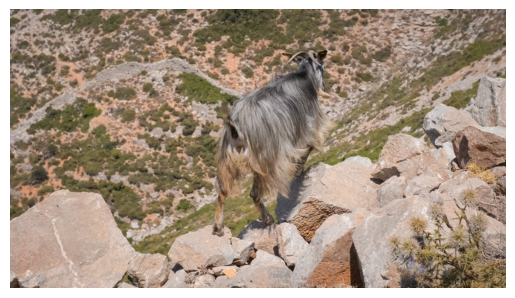

In [4]:
import matplotlib.pyplot as plt

video = sample["video"]

plt.imshow(video[0])
plt.axis("off")
plt.show()

In [5]:
points = sample["points"]

print(points.shape)

(5, 90, 2)


In [6]:
print("video shape:", sample["video"].shape)
print("points shape:", sample["points"].shape)
print("occluded shape:", sample["occluded"].shape)

print("\nFirst 5 points:")
print(sample["points"][:5])

video shape: (90, 480, 854, 3)
points shape: (5, 90, 2)
occluded shape: (5, 90)

First 5 points:
[[[0.515288   0.34306568]
  [0.5278646  0.34861112]
  [0.53828126 0.3587963 ]
  [0.54765624 0.37453705]
  [0.5570313  0.40046296]
  [0.5643229  0.41527778]
  [0.56953126 0.4097222 ]
  [0.5721354  0.40694445]
  [0.57890624 0.4125    ]
  [0.5893229  0.41435185]
  [0.59296876 0.4162037 ]
  [0.5955211  0.4140875 ]
  [0.6059896  0.41527778]
  [0.62369794 0.41990742]
  [0.6351563  0.4300926 ]
  [0.6382812  0.43657407]
  [0.6408854  0.43842593]
  [0.6460937  0.43472221]
  [0.6539062  0.43472221]
  [0.66536456 0.4337963 ]
  [0.6773437  0.43935186]
  [0.6872396  0.4412037 ]
  [0.6924479  0.41805556]
  [0.7002604  0.38935184]
  [0.70963544 0.3726852 ]
  [0.71223956 0.3587963 ]
  [0.7049479  0.35324073]
  [0.6981771  0.35416666]
  [0.7007812  0.34675926]
  [0.70390624 0.34305555]
  [0.7007812  0.35416666]
  [0.70182294 0.37916666]
  [0.7054688  0.40324074]
  [0.7059896  0.4125    ]
  [0.7091146  0.406

In [7]:
print(sample["points"].min())
print(sample["points"].max())

0.27189782
0.8434896


In [8]:
trajectory = points[0]
print(trajectory.shape)

(90, 2)


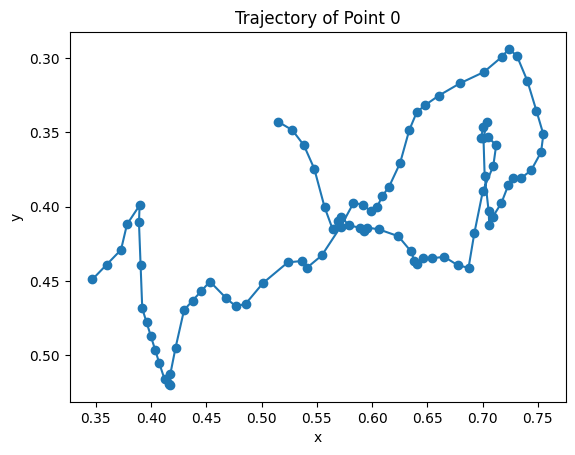

In [11]:
import matplotlib.pyplot as plt

x = trajectory[:, 0]
y = trajectory[:, 1]

plt.plot(x, y, "-o")
plt.gca().invert_yaxis()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectory of Point 0")
plt.show()

In [10]:
import cv2
import numpy as np

video = sample["video"]
points = sample["points"]
occluded = sample["occluded"]

# Choose which tracked point you want
point_id = 0

# Video dimensions
height, width = video[0].shape[:2]

# Create output video
writer = cv2.VideoWriter(
    "trajectory_overlay.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    10,
    (width, height)
)

for t, frame in enumerate(video):

    # Make a copy so we don't modify original data
    frame = frame.copy()

    x_norm, y_norm = points[point_id, t]

    x = int(x_norm * width)
    y = int(y_norm * height)

    # Draw only if the point isn't occluded
    if not occluded[point_id, t]:
        cv2.circle(
            frame,
            (int(x), int(y)),
            6,              # radius
            (255, 0, 0),    # color
            -1              # filled circle
        )

    # OpenCV expects BGR, while TAP-Vid frames are RGB
    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

    writer.write(frame)

writer.release()

print("Saved as trajectory_overlay.mp4")

Saved as trajectory_overlay.mp4
